<a href="https://colab.research.google.com/github/Fatihmaull/ARES/blob/main/midterm_fruit_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'oranges-vs-grapefruit' dataset.
Dataset berhasil dimuat!
Jumlah baris & kolom: (10000, 6)

--- Melakukan Visualisasi Data ---


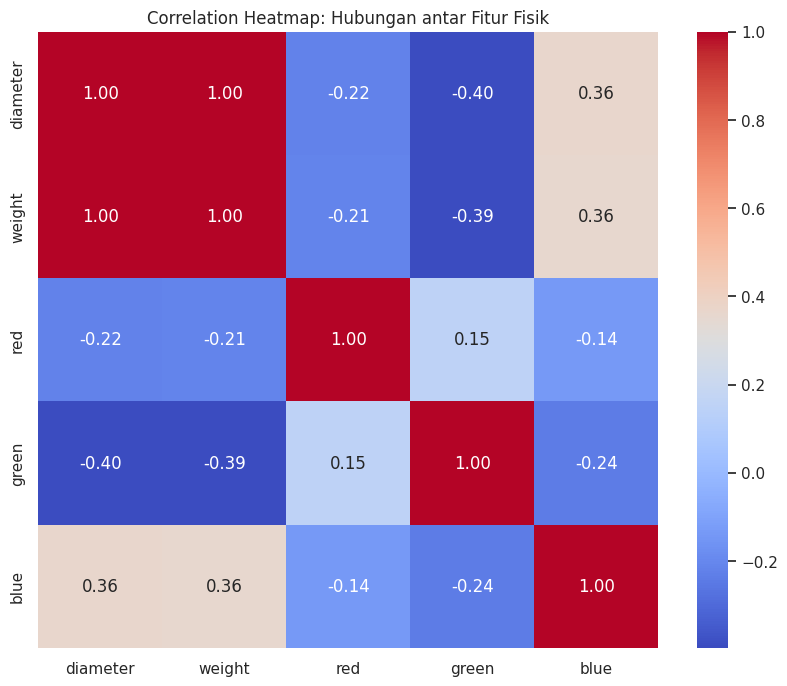

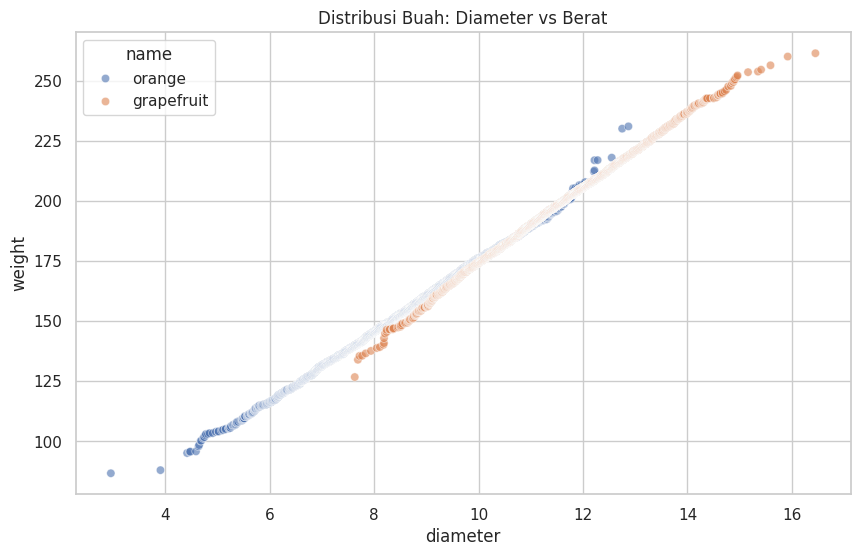


HASIL EVALUASI MODEL

>>> Model: Decision Tree
Accuracy: 0.9395
              precision    recall  f1-score   support

  grapefruit       0.93      0.94      0.94       988
      orange       0.94      0.94      0.94      1012

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000


>>> Model: Naive Bayes
Accuracy: 0.9200
              precision    recall  f1-score   support

  grapefruit       0.91      0.93      0.92       988
      orange       0.93      0.91      0.92      1012

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000


>>> Model: SVM
Accuracy: 0.9370
              precision    recall  f1-score   support

  grapefruit       0.93      0.95      0.94       988
      orange       0.95      0.92      0.94      1012

    accuracy                           0.94

/tmp/ipykernel_10899/1574981301.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')


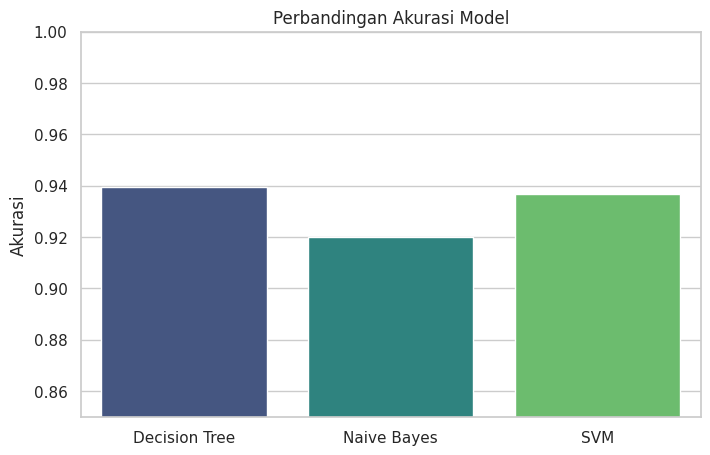

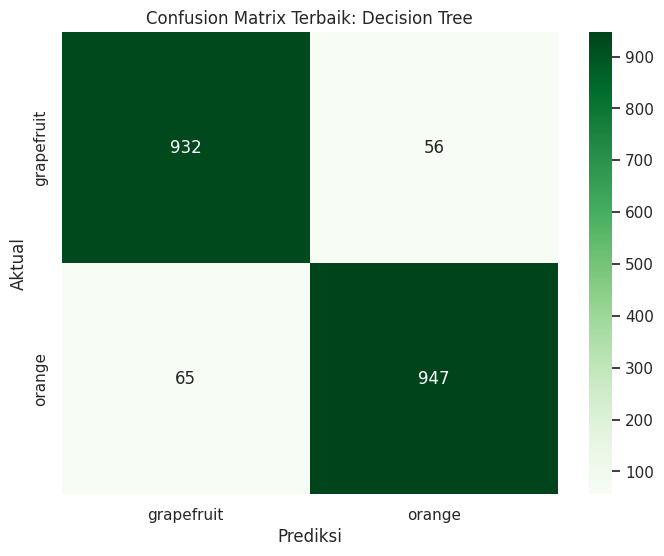


Kesimpulan: Model Decision Tree memberikan performa terbaik untuk dataset ini.


In [2]:
# 1. INSTALL & IMPORT LIBRARY
!pip install kagglehub -q
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. DOWNLOAD DATASET OTOMATIS
path = kagglehub.dataset_download("joshmcadams/oranges-vs-grapefruit")
file_path = os.path.join(path, "citrus.csv")
df = pd.read_csv(file_path)

print("Dataset berhasil dimuat!")
print(f"Jumlah baris & kolom: {df.shape}")

# 3. EXPLORATORY DATA ANALYSIS (EDA) - "Vibe Riset"
print("\n--- Melakukan Visualisasi Data ---")
sns.set(style="whitegrid")

# Visualisasi 1: Korelasi antar fitur
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Hubungan antar Fitur Fisik')
plt.show()

# Visualisasi 2: Distribusi Diameter vs Berat berdasarkan jenis buah
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='diameter', y='weight', hue='name', alpha=0.6)
plt.title('Distribusi Buah: Diameter vs Berat')
plt.show()

# 4. PREPROCESSING
le = LabelEncoder()
df['name_encoded'] = le.fit_transform(df['name']) # 0: grapefruit, 1: orange

X = df.drop(columns=['name', 'name_encoded'])
y = df['name_encoded']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 5. MODELING & COMPARISON
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC()
}

results = {}

print("\n" + "="*40)
print("HASIL EVALUASI MODEL")
print("="*40)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n>>> Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

# 6. VISUALISASI PERBANDINGAN & CONFUSION MATRIX
# Bar Plot Akurasi
plt.figure(figsize=(8, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.ylim(0.85, 1.0)
plt.title('Perbandingan Akurasi Model')
plt.ylabel('Akurasi')
plt.show()

# Confusion Matrix untuk Model Terbaik
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title(f'Confusion Matrix Terbaik: {best_model_name}')
plt.show()

print(f"\nKesimpulan: Model {best_model_name} memberikan performa terbaik untuk dataset ini.")